#  Group Project – Supply Chain Analytics with Route Optimization

- logistics management and transport mode selection
- logistics service providers and cost/service trade-offs
- warehouse management systems (WMS) and warehouse KPIs
- inventory management, safety stock, and reorder point decisions
- delivery route design using the **Travelling Salesman Problem (TSP)** with heuristics

## Concept-first project objective

Students should use analytics to support managerial decisions rather than focus on sophisticated coding. The core question is:

> How should a firm improve logistics, warehouse performance, inventory policies, and last-mile routing using data-driven analysis?

## Files expected in this project package

- `../data/demo_supply_chain_2025.csv`
- `../data/assignment_supply_chain_2025.csv`

The demonstration dataset is cleaner and smaller for reference only.  
The assignment dataset is larger and slightly noisier for student work.

---


In [ ]:
import pandas as pd
import numpy as np
import math
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import glob
import re

plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path("../data")
ASSIGNMENT_VERSIONS_DIR = DATA_DIR / "assignment_versions"
OUTPUT_DIR = Path("../outputs_demo")
CHART_DIR = OUTPUT_DIR / "charts"
OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

DEMO_FILE = DATA_DIR / "demo_supply_chain_2025.csv"
DEFAULT_ASSIGNMENT_FILE = DATA_DIR / "assignment_supply_chain_2025.csv"

In [88]:
# ============================================================
# ASSIGNMENT DATASET SELECTOR
# Change SELECTED_ASSIGNMENT_VERSION below and re-run this cell.
# This allows the same notebook to be used across 15 different
# assignment versions with meaningfully different outputs.
# ============================================================

assignment_version_files = sorted(
    [
        Path(p) for p in glob.glob(str(ASSIGNMENT_VERSIONS_DIR / "assignment_supply_chain_2025_v*.csv"))
    ]
)

assignment_version_map = {}
for path in assignment_version_files:
    match = re.search(r"assignment_supply_chain_2025_(v\d+_.+)\.csv", path.name)
    if match:
        key = match.group(1)
        pretty = key.replace("_", " ").title()
        assignment_version_map[key] = {
            "path": path,
            "label": pretty
        }

available_versions = list(assignment_version_map.keys())

# Set your selected version here:
SELECTED_ASSIGNMENT_VERSION = available_versions[3]  # Change the index to select a different version

if SELECTED_ASSIGNMENT_VERSION not in assignment_version_map:
    raise ValueError(
        f"Unknown assignment version: {SELECTED_ASSIGNMENT_VERSION}. "
        f"Choose one of: {available_versions}"
    )

ASSIGNMENT_FILE = assignment_version_map[SELECTED_ASSIGNMENT_VERSION]["path"]
ASSIGNMENT_LABEL = assignment_version_map[SELECTED_ASSIGNMENT_VERSION]["label"]
ASSIGNMENT_OUTPUT_DIR = Path(f"../outputs_{SELECTED_ASSIGNMENT_VERSION}")
ASSIGNMENT_CHART_DIR = ASSIGNMENT_OUTPUT_DIR / "charts"
ASSIGNMENT_OUTPUT_DIR.mkdir(exist_ok=True)
ASSIGNMENT_CHART_DIR.mkdir(exist_ok=True)

demo = pd.read_csv(DEMO_FILE, parse_dates=["date"])
assignment = pd.read_csv(ASSIGNMENT_FILE, parse_dates=["date"])

print("Demo dataset shape:", demo.shape)
print("Selected assignment dataset:", ASSIGNMENT_FILE.name)
print("Assignment scenario:", ASSIGNMENT_LABEL)
print("Assignment dataset shape:", assignment.shape)
print("\nAvailable assignment versions:")
for key in available_versions:
    marker = ">>" if key == SELECTED_ASSIGNMENT_VERSION else "  "
    print(f"{marker} {key} | {assignment_version_map[key]['label']}")

Demo dataset shape: (5840, 25)
Selected assignment dataset: assignment_supply_chain_2025_v04_premium_service_upgrade.csv
Assignment scenario: V04 Premium Service Upgrade
Assignment dataset shape: (16425, 25)

Available assignment versions:
   v01_urban_ecommerce_surge | V01 Urban Ecommerce Surge
   v02_rural_last_mile_expansion | V02 Rural Last Mile Expansion
   v03_lean_inventory_push | V03 Lean Inventory Push
>> v04_premium_service_upgrade | V04 Premium Service Upgrade
   v05_fuel_cost_shock | V05 Fuel Cost Shock
   v06_rail_optimization_program | V06 Rail Optimization Program
   v07_electronics_returns_crisis | V07 Electronics Returns Crisis
   v08_holiday_peak_volatility | V08 Holiday Peak Volatility
   v09_food_cold_chain_focus | V09 Food Cold Chain Focus
   v10_east_coast_supplier_disruption | V10 East Coast Supplier Disruption
   v11_south_warehouse_turnaround | V11 South Warehouse Turnaround
   v12_cost_containment_slowdown | V12 Cost Containment Slowdown
   v13_sustainability_


## 1. Understand the data

Use the dataset selector cell above to select your respective assignment version before running the analysis.

Each row represents a shipment/order line connected to a specific date, warehouse, SKU, customer location, transport mode, and provider.

### Key managerial lenses
1. **Warehouse performance:** fulfilment, speed, stockouts, and service.
2. **Inventory control:** inventory turnover logic, safety stock adequacy, reorder point discipline.
3. **Transport decisions:** cost vs service trade-off by transport mode.
4. **Provider comparison:** which logistics partner creates the best cost-service balance?
5. **Routing analytics:** can better route design lower travel cost and improve service?


In [ ]:
def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["sales_revenue_usd"] = out["units_shipped"] * out["selling_price_usd"]
    out["cogs_usd"] = out["units_shipped"] * out["unit_cost_usd"]
    out["fill_rate"] = np.where(out["units_ordered"] > 0, out["units_shipped"] / out["units_ordered"], 0)
    out["return_rate"] = np.where(out["units_shipped"] > 0, out["returns_units"] / out["units_shipped"], 0)
    out["inventory_position_gap"] = out["inventory_on_hand_units"] - out["reorder_point_units"]
    out["month"] = out["date"].dt.to_period("M").astype(str)
    return out

demo = add_derived_columns(demo)
assignment = add_derived_columns(assignment)

demo.describe(include="all").T.head(10)


## 2. Core KPI functions

In [90]:

def warehouse_kpi_summary(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("warehouse_id").agg(
        total_orders=("customer_id", "count"),
        units_ordered=("units_ordered", "sum"),
        units_shipped=("units_shipped", "sum"),
        revenue_usd=("sales_revenue_usd", "sum"),
        shipment_cost_usd=("shipment_cost_usd", "sum"),
        avg_order_lead_time_hours=("order_lead_time_hours", "mean"),
        on_time_delivery_rate=("on_time_flag", "mean"),
        stockout_rate=("stockout_flag", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
        avg_return_rate=("return_rate", "mean"),
        avg_inventory_on_hand=("inventory_on_hand_units", "mean")
    ).reset_index()

    grouped["cost_per_shipment_usd"] = grouped["shipment_cost_usd"] / grouped["total_orders"]
    grouped["revenue_per_shipment_usd"] = grouped["revenue_usd"] / grouped["total_orders"]
    grouped["inventory_turnover_proxy"] = grouped["units_shipped"] / grouped["avg_inventory_on_hand"]
    return grouped.sort_values(["on_time_delivery_rate", "avg_fill_rate"], ascending=[False, False])


def transport_mode_scorecard(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("transport_mode").agg(
        shipments=("customer_id", "count"),
        avg_distance_km=("distance_km", "mean"),
        avg_cost_usd=("shipment_cost_usd", "mean"),
        avg_lead_time_hours=("order_lead_time_hours", "mean"),
        on_time_rate=("on_time_flag", "mean"),
        fill_rate=("fill_rate", "mean"),
        gross_margin_usd=("gross_margin_usd", "mean")
    ).reset_index()
    grouped["cost_per_km"] = grouped["avg_cost_usd"] / grouped["avg_distance_km"]
    return grouped.sort_values("on_time_rate", ascending=False)


def provider_tradeoff_summary(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("logistics_provider").agg(
        shipments=("customer_id", "count"),
        avg_cost_usd=("shipment_cost_usd", "mean"),
        avg_lead_time_hours=("order_lead_time_hours", "mean"),
        on_time_rate=("on_time_flag", "mean"),
        avg_distance_km=("distance_km", "mean"),
        stockout_rate=("stockout_flag", "mean")
    ).reset_index()
    grouped["cost_service_index"] = grouped["on_time_rate"] / grouped["avg_cost_usd"]
    return grouped.sort_values(["cost_service_index", "on_time_rate"], ascending=[False, False])


def inventory_policy_recommendations(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby(["warehouse_id", "sku_id", "product_family"]).agg(
        annual_demand=("units_shipped", "sum"),
        avg_daily_demand=("units_shipped", "mean"),
        demand_std=("units_shipped", "std"),
        avg_inventory=("inventory_on_hand_units", "mean"),
        avg_safety_stock=("safety_stock_units", "mean"),
        avg_reorder_point=("reorder_point_units", "mean"),
        stockout_rate=("stockout_flag", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
    ).reset_index()

    grouped["demand_std"] = grouped["demand_std"].fillna(0)
    grouped["suggested_safety_stock"] = (1.65 * grouped["demand_std"]).round(0)
    grouped["suggested_reorder_point"] = (grouped["avg_daily_demand"] * 7 + grouped["suggested_safety_stock"]).round(0)
    grouped["inventory_turnover_proxy"] = grouped["annual_demand"] / grouped["avg_inventory"].replace(0, np.nan)

    grouped["recommendation"] = np.where(
        (grouped["stockout_rate"] > 0.08) | (grouped["avg_fill_rate"] < 0.94),
        "Increase buffer stock or improve replenishment cadence",
        np.where(
            grouped["inventory_turnover_proxy"] < 1.5,
            "Reduce inventory or rationalize slow-moving stock",
            "Current policy broadly acceptable"
        )
    )
    return grouped.sort_values(["stockout_rate", "inventory_turnover_proxy"], ascending=[False, True])


warehouse_summary_demo = warehouse_kpi_summary(demo)
transport_scorecard_demo = transport_mode_scorecard(demo)
provider_summary_demo = provider_tradeoff_summary(demo)
inventory_recommendations_demo = inventory_policy_recommendations(demo)

warehouse_summary_demo


,warehouse_id,total_orders,units_ordered,units_shipped,revenue_usd,shipment_cost_usd,avg_order_lead_time_hours,on_time_delivery_rate,stockout_rate,avg_fill_rate,avg_return_rate,avg_inventory_on_hand,cost_per_shipment_usd,revenue_per_shipment_usd,inventory_turnover_proxy
0,WH_NORTH,2920,173029,162078,20089559.93,250765.00,9.756123,0.999315,0.691781,0.935826,0.011567,516.548630,85.878425,6879.986277,313.771038
1,WH_SOUTH,2920,170817,160224,20654026.32,244082.72,10.018455,0.997945,0.696575,0.936308,0.011106,523.158904,83.589973,7073.296685,306.262588


## 3. Side-by-side KPI comparison

The next cells automatically compare the **demo dataset** with the **selected assignment version** so students can see how different scenarios produce different managerial conclusions.


In [ ]:

warehouse_summary_assignment = warehouse_kpi_summary(assignment)
transport_scorecard_assignment = transport_mode_scorecard(assignment)
provider_summary_assignment = provider_tradeoff_summary(assignment)
inventory_recommendations_assignment = inventory_policy_recommendations(assignment)

display(Markdown(f"### Demo vs Assignment warehouse KPI summary"))
display(pd.concat({
    "Demo": warehouse_summary_demo.set_index("warehouse_id"),
    ASSIGNMENT_LABEL: warehouse_summary_assignment.set_index("warehouse_id")
}, axis=1).round(3))

display(Markdown(f"### Demo vs Assignment transport mode scorecard"))
display(pd.concat({
    "Demo": transport_scorecard_demo.set_index("transport_mode"),
    ASSIGNMENT_LABEL: transport_scorecard_assignment.set_index("transport_mode")
}, axis=1).round(3))

display(Markdown(f"### Demo vs Assignment provider trade-off summary"))
display(pd.concat({
    "Demo": provider_summary_demo.set_index("logistics_provider"),
    ASSIGNMENT_LABEL: provider_summary_assignment.set_index("logistics_provider")
}, axis=1).round(3))

display(Markdown(f"### Highest-priority inventory recommendations in the selected assignment version"))
display(inventory_recommendations_assignment.head(15))


## 4. Comparative visual analysis

These charts run automatically for both datasets:
- demo dataset
- selected assignment version

Review and explain how changes in demand, inventory posture, service levels, and provider decisions lead to visibly different output.


### Part A – Warehouse Performance
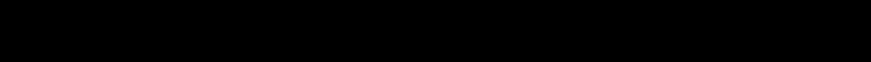

In [92]:
def format_number(x):
    if pd.isna(x):
        return ""
    if abs(x) >= 1_000_000_000:
        return f"{x/1_000_000_000:.2f}B"
    elif abs(x) >= 1_000_000:
        return f"{x/1_000_000:.2f}M"
    elif abs(x) >= 1_000:
        return f"{x/1_000:.2f}K"
    else:
        return f"{x:.0f}"

In [93]:
df_wh = warehouse_summary_assignment.copy()
df_wh = df_wh.apply(pd.to_numeric, errors='coerce')

# Keep warehouse_id
df_wh['warehouse_id'] = warehouse_summary_assignment['warehouse_id']
df_wh = df_wh.set_index('warehouse_id')

metrics = {
    'service_metrics'       : ['avg_fill_rate', 'on_time_delivery_rate',        'stockout_rate', 'avg_return_rate'    ],
    'operational_metrics'   : ['total_orders', 'units_ordered', 'units_shipped','avg_order_lead_time_hours'    ],
    'revenue_metrics'       : ['revenue_usd', 'revenue_per_shipment_usd','shipment_cost_usd', 'cost_per_shipment_usd'],
    'inventory_metrics'     : ['avg_inventory_on_hand', 'inventory_turnover_proxy'    ]
}

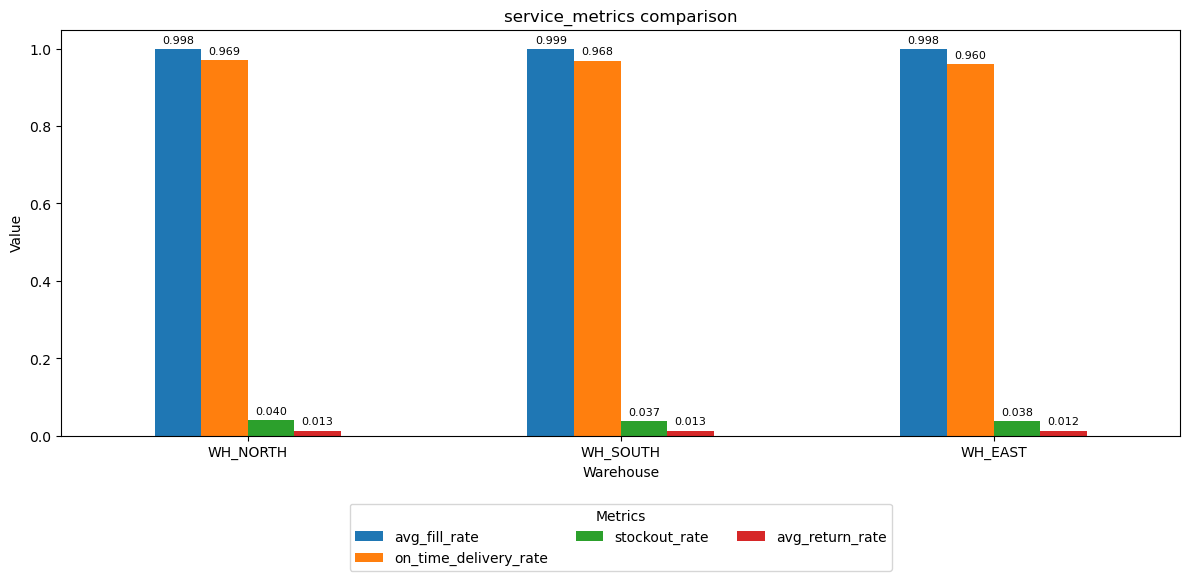

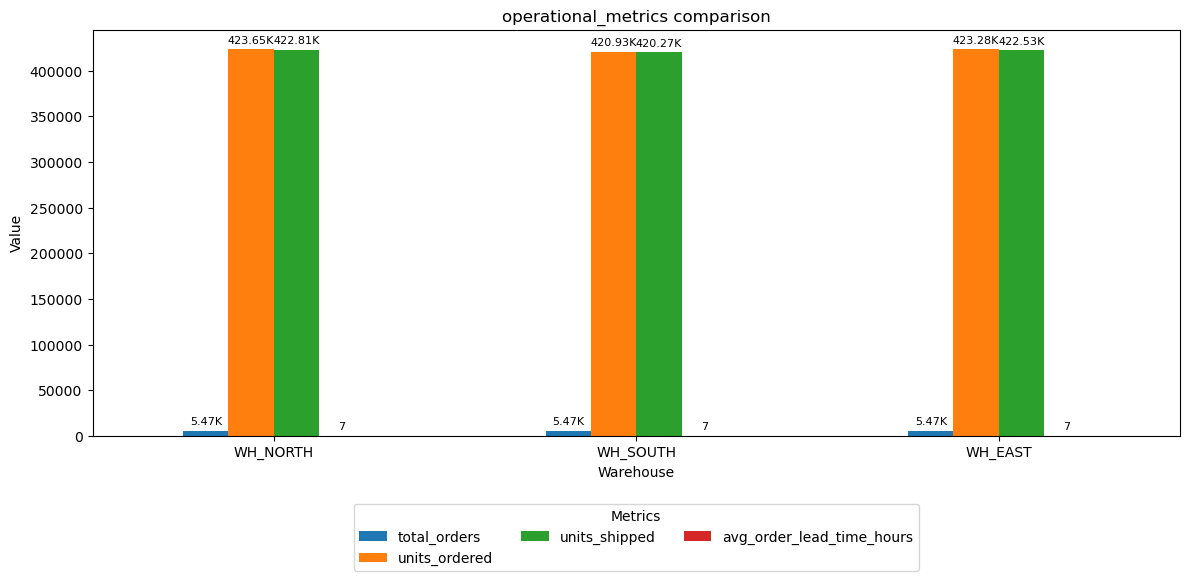

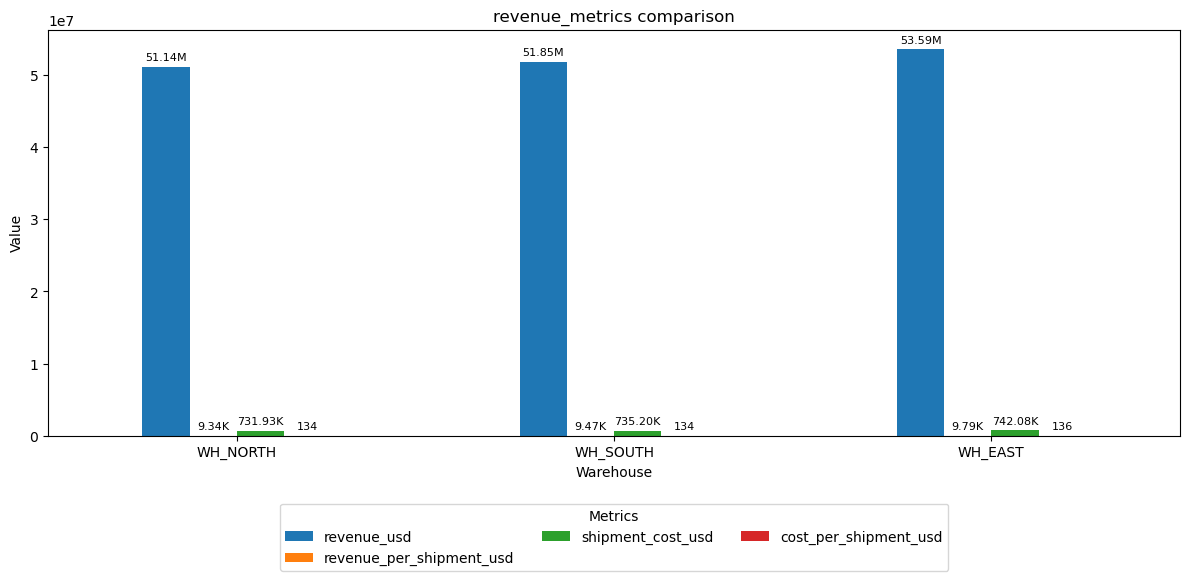

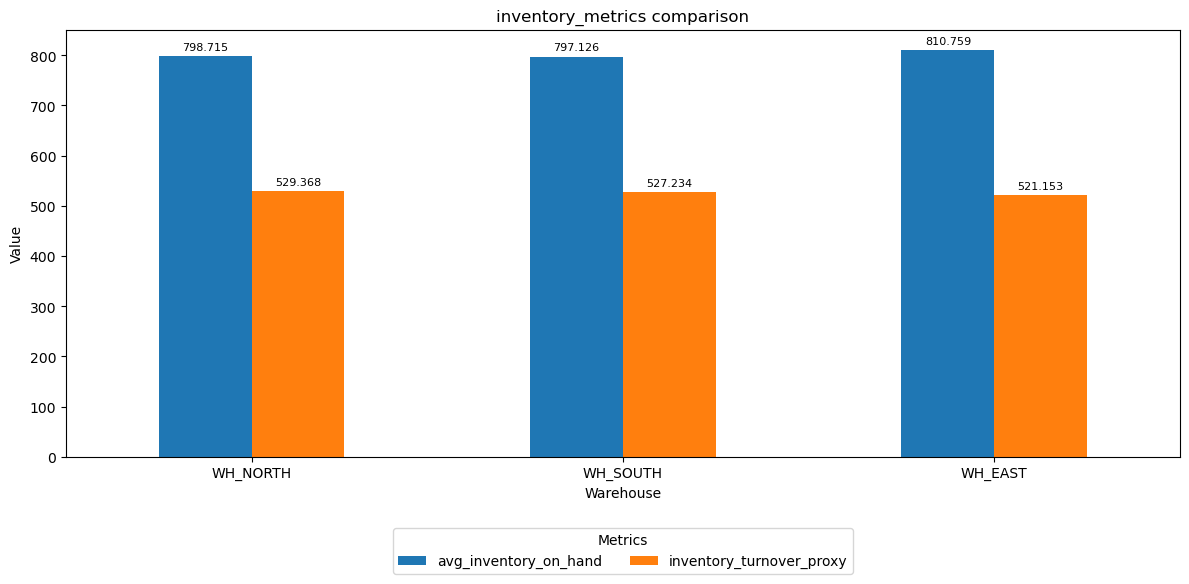

In [94]:
for category, metric_list in metrics.items():

    existing_metrics = [m for m in metric_list if m in df_wh.columns]
    if not existing_metrics:
        continue

    ax = df_wh[existing_metrics].plot(kind='bar', figsize=(12, 6))

    # White background
    ax.set_facecolor('white')
    ax.figure.set_facecolor('white')

    for container in ax.containers:

        if category == 'operational_metrics' or category == 'revenue_metrics':
            labels = [format_number(v) for v in container.datavalues]
            ax.bar_label(container, labels=labels, padding=3, fontsize=8)
        else:
            ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8)

    plt.title(f"{category} comparison")
    plt.xlabel("Warehouse")
    plt.ylabel("Value")
    plt.xticks(rotation=0)

    plt.legend(
        title="Metrics",
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=3
    )

    plt.tight_layout()
    plt.show()

### Part B – Inventory Management

In [95]:
import pandas as pd
import numpy as np

# df_inventory = your inventory dataframe
df_inv = inventory_recommendations_assignment.copy()

# -----------------------------
# 1. Create diagnostic columns
# -----------------------------

df_inv["safety_stock_gap"] = df_inv["suggested_safety_stock"] - df_inv["avg_safety_stock"]
df_inv["reorder_point_gap"] = df_inv["suggested_reorder_point"] - df_inv["avg_reorder_point"]

df_inv["safety_stock_gap_pct"] = np.where(
    df_inv["avg_safety_stock"] > 0,
    df_inv["safety_stock_gap"] / df_inv["avg_safety_stock"],
    np.nan
)

df_inv["reorder_point_gap_pct"] = np.where(
    df_inv["avg_reorder_point"] > 0,
    df_inv["reorder_point_gap"] / df_inv["avg_reorder_point"],
    np.nan
)

df_inv["demand_variability_cv"] = np.where(
    df_inv["avg_daily_demand"] > 0,
    df_inv["demand_std"] / df_inv["avg_daily_demand"],
    np.nan
)

# Inventory risk score: higher = worse
df_inv["inventory_risk_score"] = (
        df_inv["stockout_rate"] * 0.40 +
        (1 - df_inv["avg_fill_rate"]) * 0.25 +
        df_inv["demand_variability_cv"].fillna(0) * 0.20 +
        df_inv["safety_stock_gap_pct"].clip(lower=0).fillna(0) * 0.10 +
        df_inv["reorder_point_gap_pct"].clip(lower=0).fillna(0) * 0.05
)

# -----------------------------
# 2. Risk classification
# -----------------------------

def classify_inventory_risk(row):
    if row["stockout_rate"] >= 0.05 or row["avg_fill_rate"] < 0.95:
        return "High Risk"
    elif row["stockout_rate"] >= 0.03 or row["avg_fill_rate"] < 0.98:
        return "Moderate Risk"
    else:
        return "Low Risk"

df_inv["inventory_risk_level"] = df_inv.apply(classify_inventory_risk, axis=1)

# -----------------------------
# 3. Warehouse-level summary
# -----------------------------

warehouse_inventory_summary = (
    df_inv.groupby("warehouse_id")
    .agg(
        avg_stockout_rate=("stockout_rate", "mean"),
        avg_fill_rate=("avg_fill_rate", "mean"),
        avg_inventory=("avg_inventory", "mean"),
        avg_safety_stock=("avg_safety_stock", "mean"),
        avg_safety_stock_gap=("safety_stock_gap", "mean"),
        avg_reorder_point=("avg_reorder_point", "mean"),
        avg_reorder_point_gap=("reorder_point_gap", "mean"),
        avg_inventory_turnover=("inventory_turnover_proxy", "mean"),
        avg_demand_variability=("demand_variability_cv", "mean"),
        avg_inventory_risk_score=("inventory_risk_score", "mean"),
        suggested_reorder_point=("suggested_reorder_point", "mean"),
        suggested_safety_stock=("suggested_safety_stock", "mean"),
        sku_count=("sku_id", "nunique"),
        total_annual_demand=("annual_demand", "sum")
    )
    .reset_index()
    .sort_values("avg_inventory_risk_score", ascending=False)
)

inventory_metrics={
    "inventory_rates_scores":['avg_stockout_rate','avg_fill_rate','avg_demand_variability','avg_inventory_risk_score'],
    "inventory_existence":['sku_count','suggested_safety_stock','avg_reorder_point','suggested_reorder_point','avg_inventory','avg_reorder_point_gap'],
    "inventory_turnover":['avg_inventory_turnover'],
    "inventory_demand":['total_annual_demand'],
    "inventory_safety":['avg_safety_stock_gap','avg_safety_stock'],
    "inventory_risk":['avg_inventory_risk_score','inventory_risk_level'],
    "inventory_recommendations":['recommendation'],
}

warehouse_inventory_summary

,warehouse_id,avg_stockout_rate,avg_fill_rate,avg_inventory,avg_safety_stock,avg_safety_stock_gap,avg_reorder_point,avg_reorder_point_gap,avg_inventory_turnover,avg_demand_variability,avg_inventory_risk_score,suggested_reorder_point,suggested_safety_stock,sku_count,total_annual_demand
0,WH_EAST,0.037588,0.998402,811.193359,98.125396,-52.000396,216.151671,369.973329,65.180853,0.361850,0.173395,586.125,46.125,8,422530
1,WH_NORTH,0.040161,0.998281,798.201096,98.723496,-53.598496,216.956785,368.668215,66.196147,0.355079,0.172471,585.625,45.125,8,422814
2,WH_SOUTH,0.037508,0.998597,797.114062,98.728055,-53.853055,216.667816,365.457184,65.926496,0.355988,0.170887,582.125,44.875,8,420272


#### High Stockout Locations

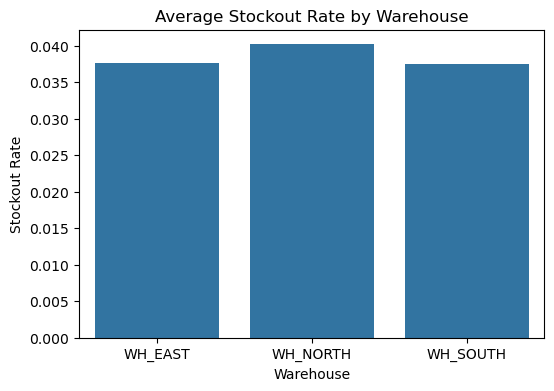

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

warehouse_stockout = (
    df_inventory.groupby("warehouse_id")["stockout_rate"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(data=warehouse_stockout, x="warehouse_id", y="stockout_rate")
plt.title("Average Stockout Rate by Warehouse")
plt.ylabel("Stockout Rate")
plt.xlabel("Warehouse")
plt.show()

#### Demand Variability vs Stockouts (Root Cause Analysis)

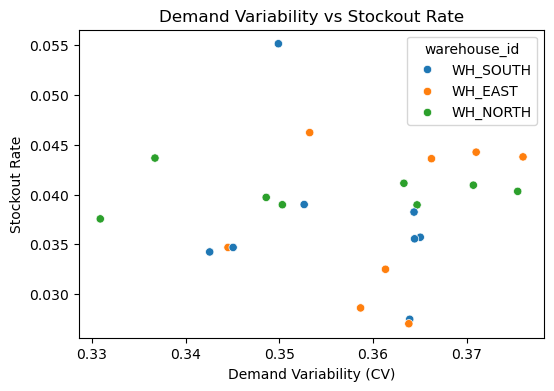

In [97]:
df_inventory["demand_variability_cv"] = (
    df_inventory["demand_std"] / df_inventory["avg_daily_demand"]
)

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_inventory,
    x="demand_variability_cv",
    y="stockout_rate",
    hue="warehouse_id"
)

plt.title("Demand Variability vs Stockout Rate")
plt.xlabel("Demand Variability (CV)")
plt.ylabel("Stockout Rate")
plt.show()

In [98]:
# -----------------------------
# 4. Product-family summary
# -----------------------------

product_family_summary = (
    df_inv.groupby("product_family")
    .agg(
        sku_count=("sku_id", "nunique"),
        total_annual_demand=("annual_demand", "sum"),
        avg_stockout_rate=("stockout_rate", "mean"),
        avg_fill_rate=("avg_fill_rate", "mean"),
        avg_safety_stock_gap=("safety_stock_gap", "mean"),
        avg_reorder_point_gap=("reorder_point_gap", "mean"),
        avg_inventory_turnover=("inventory_turnover_proxy", "mean"),
        avg_demand_variability=("demand_variability_cv", "mean"),
        avg_inventory_risk_score=("inventory_risk_score", "mean")
    )
    .reset_index()
    .sort_values("avg_inventory_risk_score", ascending=False)
)

product_family_summary

,product_family,sku_count,total_annual_demand,avg_stockout_rate,avg_fill_rate,avg_safety_stock_gap,avg_reorder_point_gap,avg_inventory_turnover,avg_demand_variability,avg_inventory_risk_score
2,Household,3,481167,0.039466,0.998344,-53.339967,367.611688,67.027520,0.360598,0.172912
1,Food,2,319861,0.035253,0.998593,-52.221573,372.089350,64.534757,0.355155,0.171923
0,Electronics,3,464588,0.039483,0.998399,-53.580714,365.749836,65.330194,0.356337,0.171808


#### Safety Stock Adequacy (Critical for Recommendations)

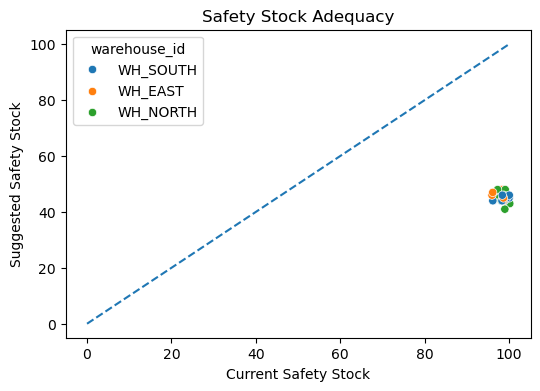

In [99]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_inventory,
    x="avg_safety_stock",
    y="suggested_safety_stock",
    hue="warehouse_id"
)

# Reference line (perfect alignment)
max_val = df_inventory[["avg_safety_stock", "suggested_safety_stock"]].max().max()
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.title("Safety Stock Adequacy")
plt.xlabel("Current Safety Stock")
plt.ylabel("Suggested Safety Stock")
plt.show()

In [100]:
# -----------------------------
# 5. Highest-risk warehouse-SKU combinations
# -----------------------------

high_risk_skus = (
    df_inv.sort_values("inventory_risk_score", ascending=False)
    [[
        "warehouse_id", "sku_id", "product_family",
        "annual_demand", "avg_daily_demand", "demand_std",
        "demand_variability_cv",
        "avg_inventory", "avg_safety_stock", "suggested_safety_stock",
        "safety_stock_gap", "avg_reorder_point", "suggested_reorder_point",
        "reorder_point_gap", "stockout_rate", "avg_fill_rate",
        "inventory_turnover_proxy", "inventory_risk_score",
        "inventory_risk_level", "recommendation"
    ]]
)

high_risk_skus.head(15)

,warehouse_id,sku_id,product_family,annual_demand,avg_daily_demand,demand_std,demand_variability_cv,avg_inventory,avg_safety_stock,suggested_safety_stock,safety_stock_gap,avg_reorder_point,suggested_reorder_point,reorder_point_gap,stockout_rate,avg_fill_rate,inventory_turnover_proxy,inventory_risk_score,inventory_risk_level,recommendation
13,WH_NORTH,SKU_F,Food,57978,77.927419,29.256836,0.375437,828.372312,97.323925,48.0,-49.323925,215.619624,593.0,377.380376,0.040323,0.998185,69.990268,0.179181,Moderate Risk,Current policy broadly acceptable
1,WH_EAST,SKU_B,Household,56923,78.731674,29.209766,0.371004,794.560166,98.655602,48.0,-50.655602,218.964039,599.0,380.035961,0.044260,0.998058,71.640893,0.179171,Moderate Risk,Current policy broadly acceptable
0,WH_EAST,SKU_A,Electronics,54328,76.734463,28.852551,0.376005,792.381356,98.290960,48.0,-50.290960,215.679379,585.0,369.320621,0.043785,0.998032,68.562946,0.178825,Moderate Risk,Current policy broadly acceptable
19,WH_SOUTH,SKU_D,Electronics,54093,78.509434,27.469915,0.349893,779.188679,98.284470,45.0,-53.284470,218.474601,595.0,376.525399,0.055152,0.997890,69.422210,0.178739,High Risk,Current policy broadly acceptable
8,WH_NORTH,SKU_A,Electronics,49955,78.669291,29.163105,0.370705,784.823622,99.137008,48.0,-51.137008,219.738583,599.0,379.261417,0.040945,0.998151,63.651244,0.177280,Moderate Risk,Current policy broadly acceptable
10,WH_NORTH,SKU_C,Food,53211,76.783550,28.002517,0.364694,813.634921,98.806638,46.0,-52.806638,215.352092,583.0,367.647908,0.038961,0.998323,65.399110,0.174302,Moderate Risk,Current policy broadly acceptable
4,WH_EAST,SKU_E,Household,50064,77.140216,27.248520,0.353234,806.520801,98.967643,45.0,-53.967643,217.682589,585.0,367.317411,0.046225,0.997473,62.074034,0.174138,Moderate Risk,Current policy broadly acceptable
7,WH_EAST,SKU_H,Household,52514,76.328488,27.953948,0.366232,820.063953,99.569767,46.0,-53.569767,218.274709,580.0,361.725291,0.043605,0.998339,64.036469,0.173964,Moderate Risk,Current policy broadly acceptable
9,WH_NORTH,SKU_B,Household,54156,76.817021,27.906841,0.363290,805.093617,99.346099,46.0,-53.346099,217.300709,584.0,366.699291,0.041135,0.998319,67.266711,0.173908,Moderate Risk,Current policy broadly acceptable
15,WH_NORTH,SKU_H,Household,55462,78.669504,27.423499,0.348591,788.696454,97.703546,45.0,-52.703546,217.794326,596.0,378.205674,0.039716,0.998538,70.321097,0.172797,Moderate Risk,Current policy broadly acceptable


#### Top High-Risk SKUs (Managerial Focus Chart)

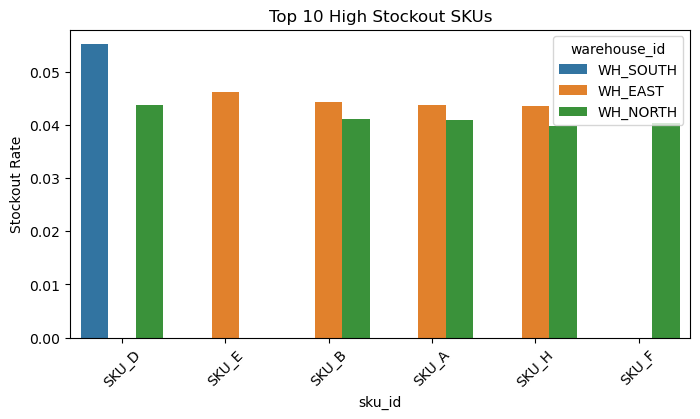

In [101]:
top_risk = df_inventory.sort_values("stockout_rate", ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(
    data=top_risk,
    x="sku_id",
    y="stockout_rate",
    hue="warehouse_id"
)

plt.title("Top 10 High Stockout SKUs")
plt.xticks(rotation=45)
plt.ylabel("Stockout Rate")
plt.show()

In [102]:
# -----------------------------
# 6. Locations with safety stock below suggested level
# -----------------------------

safety_stock_issues = (
    df_inv[df_inv["safety_stock_gap"] > 0]
    .sort_values("safety_stock_gap", ascending=False)
    [[
        "warehouse_id", "sku_id", "product_family",
        "avg_safety_stock", "suggested_safety_stock",
        "safety_stock_gap", "safety_stock_gap_pct",
        "stockout_rate", "avg_fill_rate", "annual_demand"
    ]]
)

safety_stock_issues.head(15)

,warehouse_id,sku_id,product_family,avg_safety_stock,suggested_safety_stock,safety_stock_gap,safety_stock_gap_pct,stockout_rate,avg_fill_rate,annual_demand


In [103]:
# -----------------------------
# 7. Locations with reorder points below suggested level
# -----------------------------

reorder_point_issues = (
    df_inv[df_inv["reorder_point_gap"] > 0]
    .sort_values("reorder_point_gap", ascending=False)
    [[
        "warehouse_id", "sku_id", "product_family",
        "avg_reorder_point", "suggested_reorder_point",
        "reorder_point_gap", "reorder_point_gap_pct",
        "stockout_rate", "avg_fill_rate", "annual_demand"
    ]]
)

reorder_point_issues.head(15)

,warehouse_id,sku_id,product_family,avg_reorder_point,suggested_reorder_point,reorder_point_gap,reorder_point_gap_pct,stockout_rate,avg_fill_rate,annual_demand
1,WH_EAST,SKU_B,Household,218.964039,599.0,380.035961,1.735609,0.044260,0.998058,56923
8,WH_NORTH,SKU_A,Electronics,219.738583,599.0,379.261417,1.725966,0.040945,0.998151,49955
15,WH_NORTH,SKU_H,Household,217.794326,596.0,378.205674,1.736527,0.039716,0.998538,55462
13,WH_NORTH,SKU_F,Food,215.619624,593.0,377.380376,1.750214,0.040323,0.998185,57978
19,WH_SOUTH,SKU_D,Electronics,218.474601,595.0,376.525399,1.723429,0.055152,0.997890,54093
5,WH_EAST,SKU_F,Food,213.343373,589.0,375.656627,1.760808,0.028614,0.999041,51551
3,WH_EAST,SKU_D,Electronics,214.587482,590.0,375.412518,1.749461,0.027027,0.998898,54529
18,WH_SOUTH,SKU_C,Food,214.752640,588.0,373.247360,1.738034,0.034691,0.998743,51552
21,WH_SOUTH,SKU_F,Food,217.640514,588.0,370.359486,1.701703,0.034237,0.998559,54526
0,WH_EAST,SKU_A,Electronics,215.679379,585.0,369.320621,1.712359,0.043785,0.998032,54328


#### Reorder Point Effectiveness (If column exists)

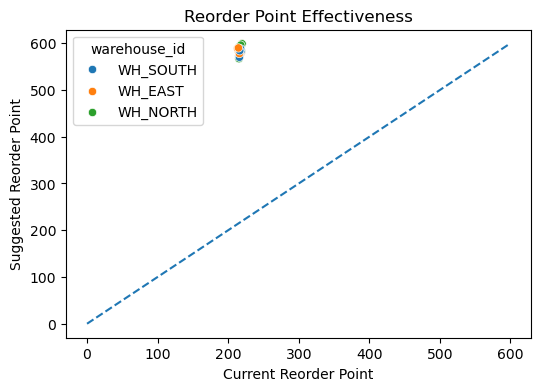

In [104]:
if "suggested_reorder_point" in df_inventory.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(
        data=df_inventory,
        x="avg_reorder_point",
        y="suggested_reorder_point",
        hue="warehouse_id"
    )

    max_val = df_inventory[["avg_reorder_point", "suggested_reorder_point"]].max().max()
    plt.plot([0, max_val], [0, max_val], linestyle="--")

    plt.title("Reorder Point Effectiveness")
    plt.xlabel("Current Reorder Point")
    plt.ylabel("Suggested Reorder Point")
    plt.show()

#### Inventory Turnover vs Stockouts (Trade-off Insight)

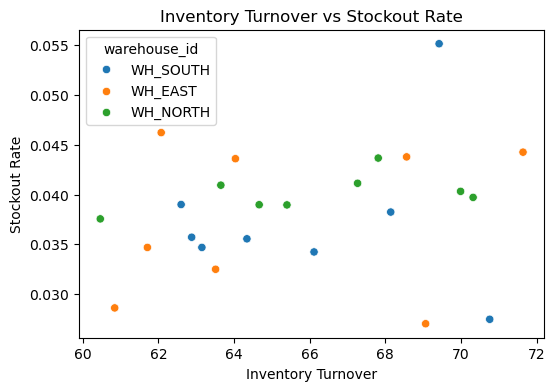

In [105]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_inventory,
    x="inventory_turnover_proxy",
    y="stockout_rate",
    hue="warehouse_id"
)

plt.title("Inventory Turnover vs Stockout Rate")
plt.xlabel("Inventory Turnover")
plt.ylabel("Stockout Rate")
plt.show()

In [106]:
# -----------------------------
# 8. Managerial recommendation summary
# -----------------------------

recommendation_summary = (
    df_inv.groupby(["warehouse_id", "recommendation"])
    .agg(
        sku_count=("sku_id", "nunique"),
        avg_stockout_rate=("stockout_rate", "mean"),
        avg_fill_rate=("avg_fill_rate", "mean"),
        avg_safety_stock_gap=("safety_stock_gap", "mean"),
        avg_reorder_point_gap=("reorder_point_gap", "mean"),
        total_annual_demand=("annual_demand", "sum")
    )
    .reset_index()
    .sort_values(["warehouse_id", "sku_count"], ascending=[True, False])
)

recommendation_summary

,warehouse_id,recommendation,sku_count,avg_stockout_rate,avg_fill_rate,avg_safety_stock_gap,avg_reorder_point_gap,total_annual_demand
0,WH_EAST,Current policy broadly acceptable,8,0.037588,0.998402,-52.000396,369.973329,422530
1,WH_NORTH,Current policy broadly acceptable,8,0.040161,0.998281,-53.598496,368.668215,422814
2,WH_SOUTH,Current policy broadly acceptable,8,0.037508,0.998597,-53.853055,365.457184,420272


In [107]:
# -----------------------------
# 9. Simple executive indicators
# -----------------------------

inventory_kpis = {
    "Total SKU-Warehouse Combinations": len(df_inv),
    "High-Risk SKU-Warehouse Combinations": (df_inv["inventory_risk_level"] == "High Risk").sum(),
    "Moderate-Risk SKU-Warehouse Combinations": (df_inv["inventory_risk_level"] == "Moderate Risk").sum(),
    "Locations Below Suggested Safety Stock": (df_inv["safety_stock_gap"] > 0).sum(),
    "Locations Below Suggested Reorder Point": (df_inv["reorder_point_gap"] > 0).sum(),
    "Average Stockout Rate": df_inv["stockout_rate"].mean(),
    "Average Fill Rate": df_inv["avg_fill_rate"].mean()
}

inventory_kpis

{'Total SKU-Warehouse Combinations': 24,
 'High-Risk SKU-Warehouse Combinations': np.int64(1),
 'Moderate-Risk SKU-Warehouse Combinations': np.int64(20),
 'Locations Below Suggested Safety Stock': np.int64(0),
 'Locations Below Suggested Reorder Point': np.int64(24),
 'Average Stockout Rate': np.float64(0.038419082455132),
 'Average Fill Rate': np.float64(0.9984270025597844)}

In [108]:
warehouse_inventory_summary
product_family_summary
high_risk_skus.head(10)
safety_stock_issues.head(10)
reorder_point_issues.head(10)
recommendation_summary
inventory_kpis

{'Total SKU-Warehouse Combinations': 24,
 'High-Risk SKU-Warehouse Combinations': np.int64(1),
 'Moderate-Risk SKU-Warehouse Combinations': np.int64(20),
 'Locations Below Suggested Safety Stock': np.int64(0),
 'Locations Below Suggested Reorder Point': np.int64(24),
 'Average Stockout Rate': np.float64(0.038419082455132),
 'Average Fill Rate': np.float64(0.9984270025597844)}

### Example Comparison

In [ ]:

def monthly_summary(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby("month").agg(
        units_ordered=("units_ordered", "sum"),
        units_shipped=("units_shipped", "sum"),
        revenue_usd=("sales_revenue_usd", "sum"),
        shipment_cost_usd=("shipment_cost_usd", "sum"),
        on_time_rate=("on_time_flag", "mean"),
        stockout_rate=("stockout_flag", "mean"),
        avg_inventory=("inventory_on_hand_units", "mean"),
    ).reset_index()


monthly_demo = monthly_summary(demo)
monthly_assignment = monthly_summary(assignment)

display(Markdown(f"### Monthly summary preview for {ASSIGNMENT_LABEL}"))
display(monthly_assignment.head())


In [ ]:

plt.figure()
plt.plot(monthly_demo["month"], monthly_demo["units_ordered"], marker="o", label="Demo Units Ordered")
plt.plot(monthly_demo["month"], monthly_demo["units_shipped"], marker="o", label="Demo Units Shipped")
plt.plot(monthly_assignment["month"], monthly_assignment["units_ordered"], marker="o", linestyle="--",
         label=f"{ASSIGNMENT_LABEL} Units Ordered")
plt.plot(monthly_assignment["month"], monthly_assignment["units_shipped"], marker="o", linestyle="--",
         label=f"{ASSIGNMENT_LABEL} Units Shipped")
plt.xticks(rotation=45)
plt.title("Monthly Demand and Shipments: Demo vs Assignment")
plt.xlabel("Month")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.savefig(ASSIGNMENT_CHART_DIR / "compare_monthly_demand_shipments.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
plt.figure()
plt.plot(monthly_demo["month"], monthly_demo["avg_inventory"], marker="o", label="Demo Avg Inventory")
plt.plot(monthly_assignment["month"], monthly_assignment["avg_inventory"], marker="o", linestyle="--",
         label=f"{ASSIGNMENT_LABEL} Avg Inventory")
plt.xticks(rotation=45)
plt.title("Average Inventory by Month: Demo vs Assignment")
plt.xlabel("Month")
plt.ylabel("Average Inventory Units")
plt.legend()
plt.tight_layout()
plt.savefig(ASSIGNMENT_CHART_DIR / "compare_monthly_inventory.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(monthly_demo["month"], monthly_demo["stockout_rate"], marker="o", label="Demo Stockout Rate")
plt.plot(monthly_assignment["month"], monthly_assignment["stockout_rate"], marker="o", linestyle="--",
         label=f"{ASSIGNMENT_LABEL} Stockout Rate")
plt.xticks(rotation=45)
plt.title("Monthly Stockout Rate: Demo vs Assignment")
plt.xlabel("Month")
plt.ylabel("Stockout Rate")
plt.legend()
plt.tight_layout()
plt.savefig(ASSIGNMENT_CHART_DIR / "compare_monthly_stockout_rate.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
warehouse_compare = pd.concat(
    [
        warehouse_summary_demo.assign(dataset="Demo"),
        warehouse_summary_assignment.assign(dataset=ASSIGNMENT_LABEL),
    ],
    ignore_index=True
)

pivot_revenue = warehouse_compare.pivot(index="warehouse_id", columns="dataset", values="revenue_usd")
pivot_ontime = warehouse_compare.pivot(index="warehouse_id", columns="dataset", values="on_time_delivery_rate")

plt.figure()
x = np.arange(len(pivot_revenue.index))
width = 0.35
demo_vals = pivot_revenue["Demo"].values
assignment_vals = pivot_revenue[ASSIGNMENT_LABEL].values
plt.bar(x - width / 2, demo_vals, width=width, label="Demo")
plt.bar(x + width / 2, assignment_vals, width=width, label=ASSIGNMENT_LABEL)
plt.xticks(x, pivot_revenue.index)
plt.title("Warehouse Revenue Comparison")
plt.xlabel("Warehouse")
plt.ylabel("Revenue USD")
plt.legend()
plt.tight_layout()
plt.savefig(ASSIGNMENT_CHART_DIR / "compare_warehouse_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
demo_ontime = pivot_ontime["Demo"].values
assignment_ontime = pivot_ontime[ASSIGNMENT_LABEL].values
plt.bar(x - width / 2, demo_ontime, width=width, label="Demo")
plt.bar(x + width / 2, assignment_ontime, width=width, label=ASSIGNMENT_LABEL)
plt.xticks(x, pivot_ontime.index)
plt.title("Warehouse On-time Delivery Comparison")
plt.xlabel("Warehouse")
plt.ylabel("On-time Delivery Rate")
plt.legend()
plt.tight_layout()
plt.savefig(ASSIGNMENT_CHART_DIR / "compare_warehouse_on_time.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
mode_compare = pd.concat(
    [
        transport_scorecard_demo.assign(dataset="Demo"),
        transport_scorecard_assignment.assign(dataset=ASSIGNMENT_LABEL),
    ],
    ignore_index=True
)

provider_compare = pd.concat(
    [
        provider_summary_demo.assign(dataset="Demo"),
        provider_summary_assignment.assign(dataset=ASSIGNMENT_LABEL),
    ],
    ignore_index=True
)

plt.figure()
for dataset_name, subset in mode_compare.groupby("dataset"):
    plt.scatter(subset["avg_cost_usd"], subset["on_time_rate"], label=dataset_name)
    for _, row in subset.iterrows():
        plt.annotate(f"{row['transport_mode']} ({dataset_name})", (row["avg_cost_usd"], row["on_time_rate"]))
plt.title("Transport Mode Cost vs Service: Demo vs Assignment")
plt.xlabel("Average Shipment Cost USD")
plt.ylabel("On-time Delivery Rate")
plt.legend()
plt.tight_layout()
plt.savefig(ASSIGNMENT_CHART_DIR / "compare_transport_mode_cost_service.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
for dataset_name, subset in provider_compare.groupby("dataset"):
    plt.scatter(subset["avg_cost_usd"], subset["on_time_rate"], label=dataset_name)
    for _, row in subset.iterrows():
        plt.annotate(f"{row['logistics_provider']} ({dataset_name})", (row["avg_cost_usd"], row["on_time_rate"]))
plt.title("Provider Cost vs Service: Demo vs Assignment")
plt.xlabel("Average Shipment Cost USD")
plt.ylabel("On-time Delivery Rate")
plt.legend()
plt.tight_layout()
plt.savefig(ASSIGNMENT_CHART_DIR / "compare_provider_cost_service.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
family_demo = demo.groupby("product_family")["sales_revenue_usd"].sum().sort_values(ascending=False)
family_assignment = assignment.groupby("product_family")["sales_revenue_usd"].sum().sort_values(ascending=False)

family_compare = pd.concat(
    [family_demo.rename("Demo"), family_assignment.rename(ASSIGNMENT_LABEL)],
    axis=1
).fillna(0)

plt.figure()
x = np.arange(len(family_compare.index))
width = 0.35
plt.bar(x - width / 2, family_compare["Demo"].values, width=width, label="Demo")
plt.bar(x + width / 2, family_compare[ASSIGNMENT_LABEL].values, width=width, label=ASSIGNMENT_LABEL)
plt.xticks(x, family_compare.index, rotation=45)
plt.title("Product Family Revenue Mix: Demo vs Assignment")
plt.xlabel("Product Family")
plt.ylabel("Revenue USD")
plt.legend()
plt.tight_layout()
plt.savefig(ASSIGNMENT_CHART_DIR / "compare_product_family_revenue_mix.png", dpi=150, bbox_inches="tight")
plt.show()


### Part C – Transport Mode and Provider Analysis
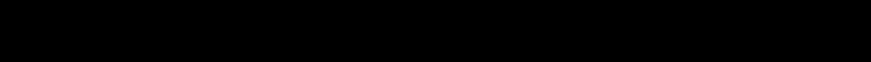

In [113]:
transport_scorecard_assignment.columns

Index(['transport_mode', 'shipments', 'avg_distance_km', 'avg_cost_usd',
       'avg_lead_time_hours', 'on_time_rate', 'fill_rate', 'gross_margin_usd',
       'cost_per_km'],
      dtype='object')

In [114]:
mode_analysis = transport_scorecard_assignment.copy()

mode_analysis["cost_rank"] = mode_analysis["avg_cost_usd"].rank(ascending=True)
mode_analysis["cost_per_km_rank"] = mode_analysis["cost_per_km"].rank(ascending=True)
mode_analysis["lead_time_rank"] = mode_analysis["avg_lead_time_hours"].rank(ascending=True)
mode_analysis["on_time_rank"] = mode_analysis["on_time_rate"].rank(ascending=False)
mode_analysis["fill_rate_rank"] = mode_analysis["fill_rate"].rank(ascending=False)
mode_analysis["margin_rank"] = mode_analysis["gross_margin_usd"].rank(ascending=False)

mode_analysis["balanced_score"] = (
    mode_analysis["on_time_rank"] * 0.30 +
    mode_analysis["fill_rate_rank"] * 0.20 +
    mode_analysis["lead_time_rank"] * 0.20 +
    mode_analysis["cost_per_km_rank"] * 0.20 +
    mode_analysis["margin_rank"] * 0.10
)

mode_analysis = mode_analysis.sort_values("balanced_score")

mode_analysis

,transport_mode,shipments,avg_distance_km,avg_cost_usd,avg_lead_time_hours,on_time_rate,fill_rate,gross_margin_usd,cost_per_km,cost_rank,cost_per_km_rank,lead_time_rank,on_time_rank,fill_rate_rank,margin_rank,balanced_score
0,Air,6574,85.318768,200.815853,5.598836,0.985397,0.998609,3386.078645,2.353713,3.0,3.0,1.0,1.0,1.0,1.0,1.4
2,Road,7373,73.550857,89.328355,7.498527,0.960125,0.998365,2475.335778,1.214511,1.0,2.0,2.0,2.0,2.0,2.0,2.0
1,Rail,2478,106.446400,92.985650,9.198910,0.929379,0.998127,2235.103890,0.873544,2.0,1.0,3.0,3.0,3.0,3.0,2.6


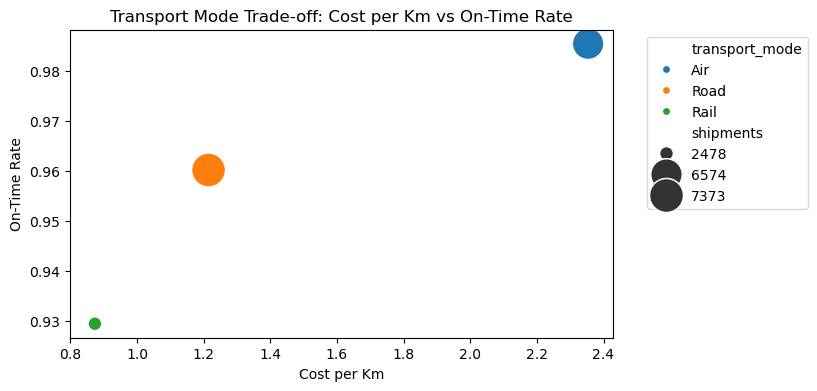

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=mode_analysis,
    x="cost_per_km",
    y="on_time_rate",
    size="shipments",
    hue="transport_mode",
    sizes=(100, 600)
)
plt.title("Transport Mode Trade-off: Cost per Km vs On-Time Rate")
plt.xlabel("Cost per Km")
plt.ylabel("On-Time Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

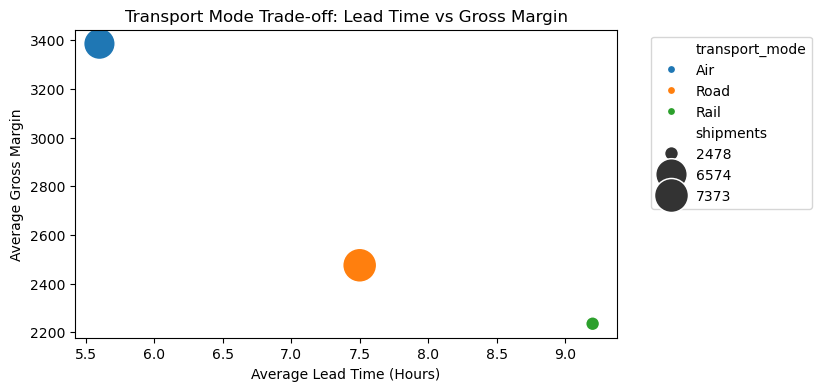

In [116]:
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=mode_analysis,
    x="avg_lead_time_hours",
    y="gross_margin_usd",
    size="shipments",
    hue="transport_mode",
    sizes=(100, 600)
)
plt.title("Transport Mode Trade-off: Lead Time vs Gross Margin")
plt.xlabel("Average Lead Time (Hours)")
plt.ylabel("Average Gross Margin")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [121]:
provider_scorecard = (
    assignment.groupby("logistics_provider")
    .agg(
        shipments=("customer_id", "count"),
        avg_distance_km=("distance_km", "mean"),
        avg_cost_usd=("shipment_cost_usd", "mean"),
        avg_lead_time_hours=("order_lead_time_hours", "mean"),
        on_time_rate=("on_time_flag", "mean"),
        fill_rate=("fill_rate", "mean"),
        gross_margin_usd=("gross_margin_usd", "mean"),
        lead_time_std=("order_lead_time_hours", "std"),
        cost_std=("shipment_cost_usd", "std")
    )
    .reset_index()
)

provider_scorecard["cost_per_km"] = (
    provider_scorecard["avg_cost_usd"] / provider_scorecard["avg_distance_km"]
)

provider_scorecard = provider_scorecard.sort_values("on_time_rate", ascending=False)

provider_scorecard

,logistics_provider,shipments,avg_distance_km,avg_cost_usd,avg_lead_time_hours,on_time_rate,fill_rate,gross_margin_usd,lead_time_std,cost_std,cost_per_km
1,Provider_Y,7271,82.667632,142.834463,6.613679,0.986522,0.998574,2792.866450,2.539744,120.219549,1.727816
0,Provider_X,5268,85.351023,126.648128,7.243197,0.960896,0.998366,2758.410192,2.860897,103.681162,1.483850
2,Provider_Z,3886,81.380517,129.559470,7.370836,0.932836,0.998234,2884.992869,2.906135,109.755922,1.592021


In [122]:
provider_analysis = provider_scorecard.copy()

provider_analysis["cost_per_km_rank"] = provider_analysis["cost_per_km"].rank(ascending=True)
provider_analysis["lead_time_rank"] = provider_analysis["avg_lead_time_hours"].rank(ascending=True)
provider_analysis["on_time_rank"] = provider_analysis["on_time_rate"].rank(ascending=False)
provider_analysis["fill_rate_rank"] = provider_analysis["fill_rate"].rank(ascending=False)
provider_analysis["margin_rank"] = provider_analysis["gross_margin_usd"].rank(ascending=False)
provider_analysis["lead_time_consistency_rank"] = provider_analysis["lead_time_std"].rank(ascending=True)

provider_analysis["balanced_score"] = (
    provider_analysis["on_time_rank"] * 0.30 +
    provider_analysis["fill_rate_rank"] * 0.15 +
    provider_analysis["lead_time_rank"] * 0.20 +
    provider_analysis["cost_per_km_rank"] * 0.20 +
    provider_analysis["lead_time_consistency_rank"] * 0.10 +
    provider_analysis["margin_rank"] * 0.05
)

provider_analysis = provider_analysis.sort_values("balanced_score")

provider_analysis

,logistics_provider,shipments,avg_distance_km,avg_cost_usd,avg_lead_time_hours,on_time_rate,fill_rate,gross_margin_usd,lead_time_std,cost_std,cost_per_km,cost_per_km_rank,lead_time_rank,on_time_rank,fill_rate_rank,margin_rank,lead_time_consistency_rank,balanced_score
1,Provider_Y,7271,82.667632,142.834463,6.613679,0.986522,0.998574,2792.866450,2.539744,120.219549,1.727816,3.0,1.0,1.0,1.0,2.0,1.0,1.45
0,Provider_X,5268,85.351023,126.648128,7.243197,0.960896,0.998366,2758.410192,2.860897,103.681162,1.483850,1.0,2.0,2.0,2.0,3.0,2.0,1.85
2,Provider_Z,3886,81.380517,129.559470,7.370836,0.932836,0.998234,2884.992869,2.906135,109.755922,1.592021,2.0,3.0,3.0,3.0,1.0,3.0,2.70


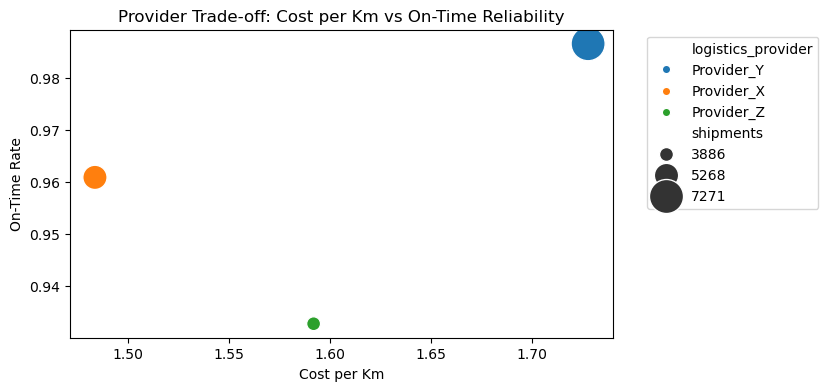

In [123]:
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=provider_analysis,
    x="cost_per_km",
    y="on_time_rate",
    size="shipments",
    hue="logistics_provider",
    sizes=(100, 600)
)
plt.title("Provider Trade-off: Cost per Km vs On-Time Reliability")
plt.xlabel("Cost per Km")
plt.ylabel("On-Time Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## 5. Managerial interpretation helper

This cell creates concise executive summaries for both the demo dataset and the selected assignment version.

In [ ]:
'''
DEMO DATASET SUMMARY

Executive Summary foundations

1. WH_NORTH currently leads on service performance, with on-time delivery of 99.9%
   and an average fill rate of 93.6%.

2. WH_SOUTH has the longest average order lead time at 10.0 hours,
   suggesting process or routing improvement opportunities.

3. Across transport modes, Rail delivers the strongest on-time performance at
   100.0%, although managers should still compare that advantage against cost.

4. The lowest average shipment cost is currently delivered by Provider_Y,
   but provider choice should be based on both cost and service, not cost alone.

5. Inventory analysis shows that SKU_D in WH_NORTH has a stockout rate of
   72.5%. This item should be prioritized for reorder-point and safety-stock review.

6. The business should not treat warehouse, inventory, transport, and routing decisions as separate silos.
   Their performance is operationally linked and should be managed as one coordinated supply chain system.

================================================================================

ASSIGNMENT DATASET SUMMARY: V03 Lean Inventory Push

Executive Summary foundations

1. WH_NORTH currently leads on service performance, with on-time delivery of 86.8%
   and an average fill rate of 90.5%.

2. WH_EAST has the longest average order lead time at 9.2 hours,
   suggesting process or routing improvement opportunities.

3. Across transport modes, Air delivers the strongest on-time performance at
   90.3%, although managers should still compare that advantage against cost.

4. The lowest average shipment cost is currently delivered by Provider_X,
   but provider choice should be based on both cost and service, not cost alone.

5. Inventory analysis shows that SKU_D in WH_NORTH has a stockout rate of
   77.6%. This item should be prioritized for reorder-point and safety-stock review.

6. The business should not treat warehouse, inventory, transport, and routing decisions as separate silos.
   Their performance is operationally linked and should be managed as one coordinated supply chain system.

'''


## 6. Traveling Salesman Problem (TSP) section

### Why TSP belongs in this project
The uploaded logistics and warehouse topics naturally extend into **delivery route optimization**. Once a company decides *what* to ship, *from where*, and *with which transport/provider*, it still must decide the **sequence of customer stops**.

The TSP asks:

> Given a starting depot and a set of customer locations, what route visits each location once and returns to the depot at the minimum total travel distance?

The important lesson is not proving optimality mathematically.  
The important lesson is understanding how **heuristics** create **fast, practical, near-optimal solutions** for real-world operations.

### Heuristics implemented here
1. **Nearest Neighbor (NN)** – build a route greedily by always choosing the closest next stop.
2. **2-opt improvement** – improve an existing route by swapping route segments when distance falls.
3. **Random baseline** – a simple comparison benchmark.


In [125]:
WAREHOUSE_COORDS = {
    "WH_NORTH": (41.8781, -87.6298),
    "WH_SOUTH": (29.7604, -95.3698),
    "WH_EAST": (33.7490, -84.3880),
}


def euclidean_km(lat1, lon1, lat2, lon2):
    dx = (lon2 - lon1) * 85
    dy = (lat2 - lat1) * 111
    return math.sqrt(dx ** 2 + dy ** 2)


def route_distance(points, route):
    total = 0.0
    for i in range(len(route) - 1):
        a = points[route[i]]
        b = points[route[i + 1]]
        total += euclidean_km(a[0], a[1], b[0], b[1])
    return total


def nearest_neighbor_route(points):
    unvisited = list(range(1, len(points)))
    route = [0]
    while unvisited:
        last = route[-1]
        next_city = min(unvisited,
                        key=lambda j: euclidean_km(points[last][0], points[last][1], points[j][0], points[j][1]))
        route.append(next_city)
        unvisited.remove(next_city)
    route.append(0)
    return route


def random_route(points, seed=7):
    rng = np.random.default_rng(seed)
    inner = list(range(1, len(points)))
    rng.shuffle(inner)
    return [0] + inner + [0]


def two_opt(points, route):
    best = route[:]
    improved = True
    while improved:
        improved = False
        best_distance = route_distance(points, best)
        for i in range(1, len(best) - 2):
            for j in range(i + 1, len(best) - 1):
                if j - i == 1:
                    continue
                candidate = best[:]
                candidate[i:j] = best[j - 1:i - 1:-1]
                candidate_distance = route_distance(points, candidate)
                if candidate_distance < best_distance:
                    best = candidate
                    best_distance = candidate_distance
                    improved = True
        route = best
    return best


def build_tsp_instance(df: pd.DataFrame, warehouse_id: str, service_date: str, n_customers: int = 12):
    subset = df[(df["warehouse_id"] == warehouse_id) & (df["date"] == pd.to_datetime(service_date))].copy()
    subset = subset.sort_values("units_ordered", ascending=False).head(n_customers)

    if subset.empty:
        raise ValueError("No shipments found for the selected warehouse/date.")

    depot = WAREHOUSE_COORDS[warehouse_id]
    point_labels = ["DEPOT"] + subset["customer_id"].tolist()
    points = [depot] + list(zip(subset["customer_latitude"], subset["customer_longitude"]))
    tsp_df = pd.DataFrame({
        "label": point_labels,
        "latitude": [p[0] for p in points],
        "longitude": [p[1] for p in points],
    })
    return points, tsp_df, subset


points, tsp_nodes, tsp_orders = build_tsp_instance(assignment, "WH_SOUTH", "2025-07-15", n_customers=10)
tsp_nodes


,label,latitude,longitude
0,DEPOT,29.760400,-95.369800
1,C9871,29.277040,-95.737885
2,C6551,29.755509,-96.919841
3,C7163,29.622141,-94.705132
4,C2776,30.293000,-95.111870
5,C2375,31.389590,-93.869350
6,C3944,30.571364,-95.168671
7,C6596,30.309451,-94.885943
8,C8846,30.147768,-94.709271
9,C6922,28.545847,-94.977550


In [126]:
baseline = random_route(points, seed=7)
nn_route = nearest_neighbor_route(points)
two_opt_route = two_opt(points, nn_route)

comparison = pd.DataFrame({
    "method": ["Random Baseline", "Nearest Neighbor", "Nearest Neighbor + 2-opt"],
    "total_distance_km": [
        route_distance(points, baseline),
        route_distance(points, nn_route),
        route_distance(points, two_opt_route)
    ]
}).sort_values("total_distance_km")

comparison["distance_reduction_vs_random"] = (
        (comparison["total_distance_km"].max() - comparison["total_distance_km"]) / comparison[
    "total_distance_km"].max()
)

comparison


,method,total_distance_km,distance_reduction_vs_random
2,Nearest Neighbor + 2-opt,938.415198,0.307359
1,Nearest Neighbor,1070.361813,0.209970
0,Random Baseline,1354.836910,0.000000


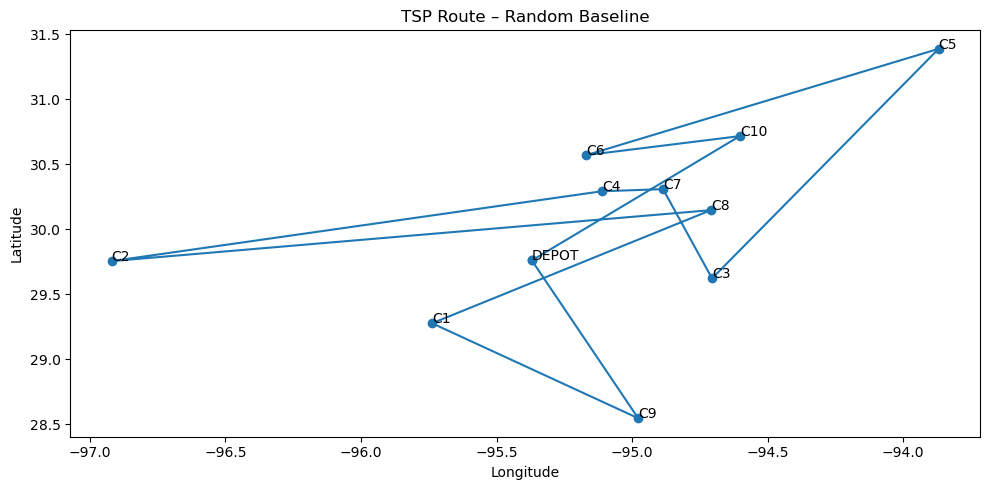

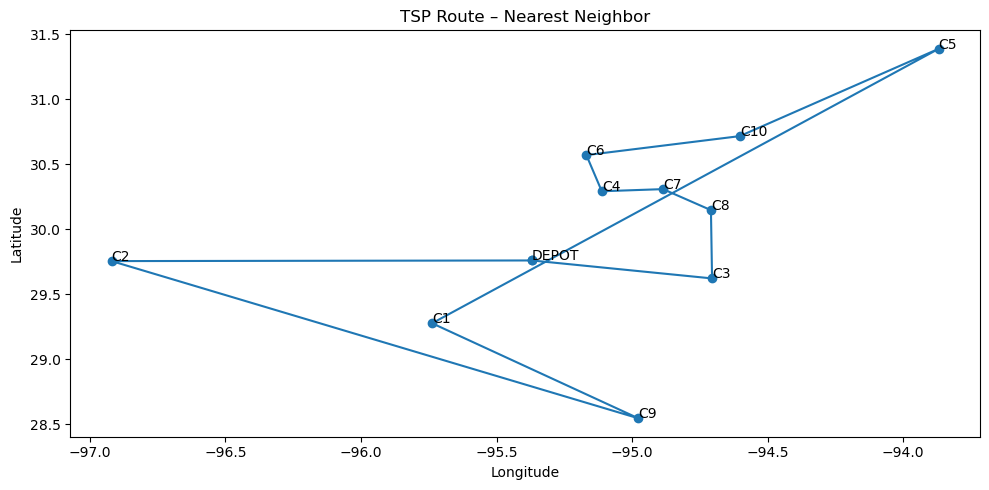

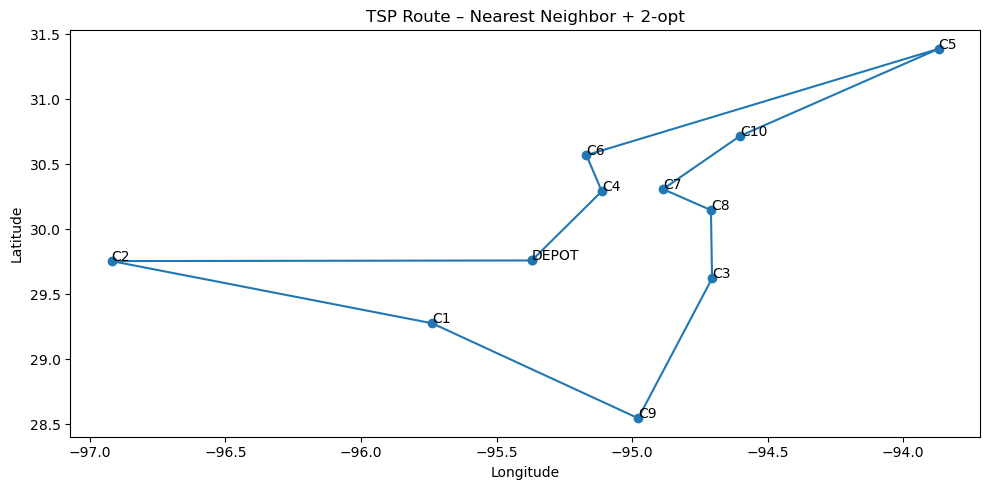

In [127]:

def plot_route(points, route, title, filename=None):
    xs = [points[i][1] for i in route]
    ys = [points[i][0] for i in route]

    plt.figure()
    plt.plot(xs, ys, marker="o")
    for idx, point_index in enumerate(route[:-1]):
        label = "DEPOT" if point_index == 0 else f"C{point_index}"
        plt.annotate(label, (points[point_index][1], points[point_index][0]))
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    if filename:
        plt.savefig(CHART_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


plot_route(points, baseline, "TSP Route – Random Baseline", "tsp_random_baseline.png")
plot_route(points, nn_route, "TSP Route – Nearest Neighbor", "tsp_nearest_neighbor.png")
plot_route(points, two_opt_route, "TSP Route – Nearest Neighbor + 2-opt", "tsp_two_opt.png")



### Managerial interpretation of the TSP results

Students should discuss issues such as:
- Why a heuristic route can meaningfully reduce total delivery distance.
- How distance reduction can influence cost, emissions, utilization, and customer service windows.
- Why a good route is still only one part of the broader logistics system.
- Why managers often accept *near-optimal* solutions when they are fast, transparent, and operationally usable.

this is a useful bridge from **warehouse/inventory analytics** to **network and transportation decision making**.


## 7. Export outputs


In [17]:

# Export demo outputs
warehouse_summary_demo.to_csv(OUTPUT_DIR / "warehouse_kpi_summary.csv", index=False)
transport_scorecard_demo.to_csv(OUTPUT_DIR / "transport_mode_scorecard.csv", index=False)
provider_summary_demo.to_csv(OUTPUT_DIR / "provider_tradeoff_summary.csv", index=False)
inventory_recommendations_demo.to_csv(OUTPUT_DIR / "inventory_policy_recommendations.csv", index=False)
comparison.to_csv(OUTPUT_DIR / "tsp_route_comparison.csv", index=False)

# Export selected assignment outputs
warehouse_summary_assignment.to_csv(ASSIGNMENT_OUTPUT_DIR / "warehouse_kpi_summary.csv", index=False)
transport_scorecard_assignment.to_csv(ASSIGNMENT_OUTPUT_DIR / "transport_mode_scorecard.csv", index=False)
provider_summary_assignment.to_csv(ASSIGNMENT_OUTPUT_DIR / "provider_tradeoff_summary.csv", index=False)
inventory_recommendations_assignment.to_csv(ASSIGNMENT_OUTPUT_DIR / "inventory_policy_recommendations.csv", index=False)
comparison.to_csv(ASSIGNMENT_OUTPUT_DIR / "tsp_route_comparison.csv", index=False)

print("Demo outputs exported to:", OUTPUT_DIR.resolve())
print("Demo charts exported to:", CHART_DIR.resolve())
print("Selected assignment outputs exported to:", ASSIGNMENT_OUTPUT_DIR.resolve())
print("Selected assignment charts exported to:", ASSIGNMENT_CHART_DIR.resolve())


Demo outputs exported to: I:\My Drive\3. OSU - Oklahoma\8. Academic\BAN 5763 Adv Marketing Research Analytics\Final Exercise Supply Chain\Exercise_Repo_Code\outputs_demo
Demo charts exported to: I:\My Drive\3. OSU - Oklahoma\8. Academic\BAN 5763 Adv Marketing Research Analytics\Final Exercise Supply Chain\Exercise_Repo_Code\outputs_demo\charts
Selected assignment outputs exported to: I:\My Drive\3. OSU - Oklahoma\8. Academic\BAN 5763 Adv Marketing Research Analytics\Final Exercise Supply Chain\Exercise_Repo_Code\outputs_v04_premium_service_upgrade
Selected assignment charts exported to: I:\My Drive\3. OSU - Oklahoma\8. Academic\BAN 5763 Adv Marketing Research Analytics\Final Exercise Supply Chain\Exercise_Repo_Code\outputs_v04_premium_service_upgrade\charts
